 this was used to analyze ~260 single day sim runs. The analysis was reltivly simple looking at a few perams: 
     "traffic_percentile", "bus_prior", "bus_interval", "car_toll" 
 and how they influenced 
     "cumulitive_time_lost" and "avg_realized_tt"

The total sim took about 7 hours

Summary of findings:
    There is a trade off between two seperate ques, the road que and the bus que. If the toll promotes bus ridership in excess of bus capasity, Travel times increase. 
    Thus there is an optimal toll even in regards to travel time



# Imports

In [128]:
import os
from pathlib import Path
import subprocess

# Get the top-level directory of the current git repo
PROJECT_ROOT = Path(
    subprocess.check_output(
        ["git", "rev-parse", "--show-toplevel"], text=True
    ).strip()
)

os.chdir(PROJECT_ROOT)




# Enable auto-reloading of custom modules
%load_ext autoreload
%autoreload 2
%pwd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('/Users/zanderholleran/Desktop/python_projects/mesa_lcc_model/data/traffic_experiment/single_day_experiment_results.csv')

In [8]:
display(df.head())
df.shape

,seed,traffic_percentile,car_toll,avg_realized_tt,avg_cumtime_lost_sec,bus_interval,bus_prior,n_car,n_bus
0,1,50,0,20.148972,121.202121,10,30,1216,0
1,2,50,0,20.122597,119.578339,10,30,1276,0
2,1,50,0,20.101254,118.720180,10,30,1223,0
3,2,50,0,20.076228,120.349263,10,30,1283,0
4,3,50,0,20.125894,120.734553,30,30,1221,0


(234, 9)

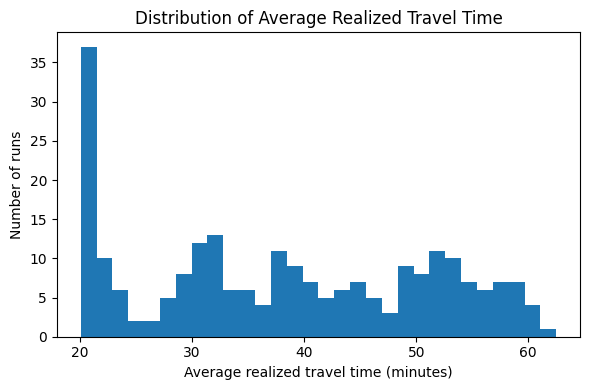

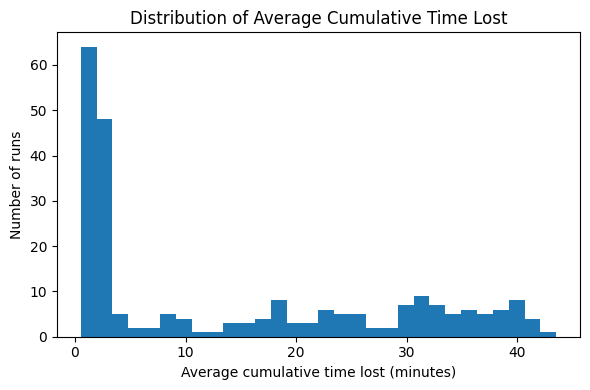

In [9]:
# -------------------------
# 2. Basic distributions
# -------------------------

plt.figure(figsize=(6, 4))
plt.hist(df["avg_realized_tt"], bins=30)
plt.title("Distribution of Average Realized Travel Time")
plt.xlabel("Average realized travel time (minutes)")
plt.ylabel("Number of runs")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(df["avg_cumtime_lost_sec"] / 60, bins=30)
plt.title("Distribution of Average Cumulative Time Lost")
plt.xlabel("Average cumulative time lost (minutes)")
plt.ylabel("Number of runs")
plt.tight_layout()
plt.show()


In [14]:
# -------------------------
# 3. Build a grouped summary table
# -------------------------

group_cols = ["traffic_percentile", "bus_prior", "bus_interval", "car_toll"]

summary = (
    df.groupby(group_cols, as_index=False)
      .agg(
          avg_tt=("avg_realized_tt", "mean"),
          avg_cum_lost_sec=("avg_cumtime_lost_sec", "mean"),
          mean_n_car=("n_car", "mean"),
          mean_n_bus=("n_bus", "mean"),
      )
)

# bus share as a percentage
summary["bus_share_pct"] = 100 * summary["mean_n_bus"] / (
    summary["mean_n_car"] + summary["mean_n_bus"]
)

print("\nSummary head:")
summary



Summary head:


,traffic_percentile,bus_prior,bus_interval,car_toll,avg_tt,avg_cum_lost_sec,mean_n_car,mean_n_bus,bus_share_pct
0,50,30,10,0,20.112263,119.962476,1249.5,0.0,0.000000
1,50,30,10,5,20.613723,102.452997,1112.0,120.0,9.740260
2,50,30,10,10,22.483095,65.188604,782.0,461.0,37.087691
3,50,30,10,20,41.942907,31.331345,306.0,525.0,63.176895
4,50,30,30,0,20.096811,118.331032,1207.5,0.0,0.000000
...,...,...,...,...,...,...,...,...,...
111,95,40,30,20,32.130687,180.497473,1080.0,180.0,14.285714
112,95,50,5,0,58.766373,2397.713558,1814.0,0.0,0.000000
113,95,50,5,5,60.290359,2488.306967,1841.5,5.5,0.297780
114,95,50,5,10,55.927124,2213.811052,1835.0,92.0,4.774261


In [16]:
print('prior', summary["bus_prior"].unique())
print('interval', summary["bus_interval"].unique())

prior [30 40 50]
interval [10 30  5]



Plotting slice with bus_prior=30, bus_interval=10


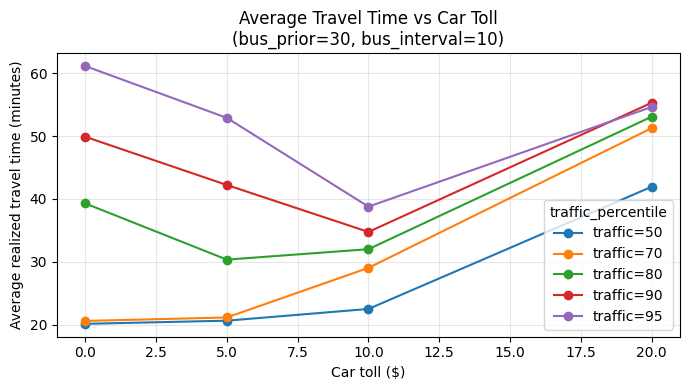

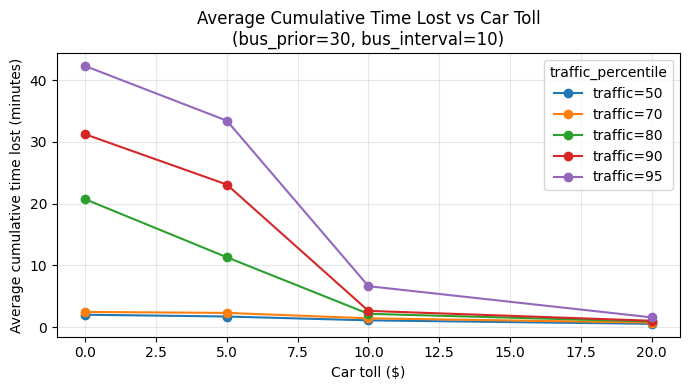

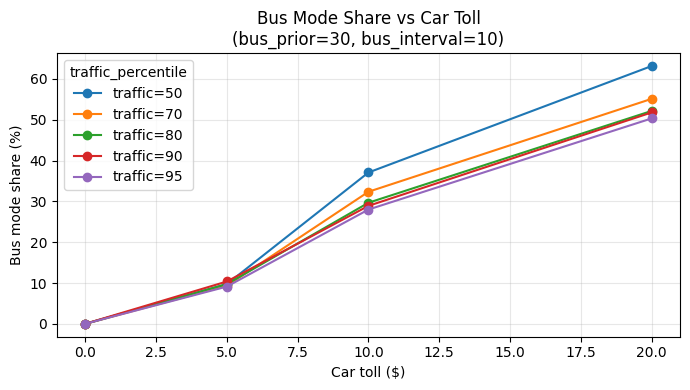

In [25]:
# -------------------------
# 4. Example slice: pick one bus_prior and bus_interval
#    and show how outcomes change with toll & traffic_percentile
# -------------------------

# adjust these to whatever slice you want to show
example_bus_prior = summary["bus_prior"].unique()[0]
example_bus_interval = summary["bus_interval"].unique()[0]

slice_df = summary[
    (summary["bus_prior"] == example_bus_prior) &
    (summary["bus_interval"] == example_bus_interval)
]

print(f"\nPlotting slice with bus_prior={example_bus_prior}, "
      f"bus_interval={example_bus_interval}")

# 4a. Average realized travel time vs toll
plt.figure(figsize=(7, 4))
for tp in sorted(slice_df["traffic_percentile"].unique()):
    sub = slice_df[slice_df["traffic_percentile"] == tp].sort_values("car_toll")
    plt.plot(sub["car_toll"], sub["avg_tt"], marker="o", label=f"traffic={tp}")

plt.title("Average Travel Time vs Car Toll\n"
          f"(bus_prior={example_bus_prior}, bus_interval={example_bus_interval})")
plt.xlabel("Car toll ($)")
plt.ylabel("Average realized travel time (minutes)")
plt.grid(alpha=0.3)
plt.legend(title="traffic_percentile")
plt.tight_layout()
plt.show()

# 4b. Average cumulative time lost vs toll
plt.figure(figsize=(7, 4))
for tp in sorted(slice_df["traffic_percentile"].unique()):
    sub = slice_df[slice_df["traffic_percentile"] == tp].sort_values("car_toll")
    plt.plot(sub["car_toll"], sub["avg_cum_lost_sec"] / 60, marker="o", label=f"traffic={tp}")

plt.title("Average Cumulative Time Lost vs Car Toll\n"
          f"(bus_prior={example_bus_prior}, bus_interval={example_bus_interval})")
plt.xlabel("Car toll ($)")
plt.ylabel("Average cumulative time lost (minutes)")
plt.grid(alpha=0.3)
plt.legend(title="traffic_percentile")
plt.tight_layout()
plt.show()

# 4c. Bus share vs toll
plt.figure(figsize=(7, 4))
for tp in sorted(slice_df["traffic_percentile"].unique()):
    sub = slice_df[slice_df["traffic_percentile"] == tp].sort_values("car_toll")
    plt.plot(sub["car_toll"], sub["bus_share_pct"], marker="o", label=f"traffic={tp}")

plt.title("Bus Mode Share vs Car Toll\n"
          f"(bus_prior={example_bus_prior}, bus_interval={example_bus_interval})")
plt.xlabel("Car toll ($)")
plt.ylabel("Bus mode share (%)")
plt.grid(alpha=0.3)
plt.legend(title="traffic_percentile")
plt.tight_layout()
plt.show()

# -------------------------
# 5. Optional: facet by bus_prior or bus_interval in loops
#    (uncomment if you want more plots)
# -------------------------

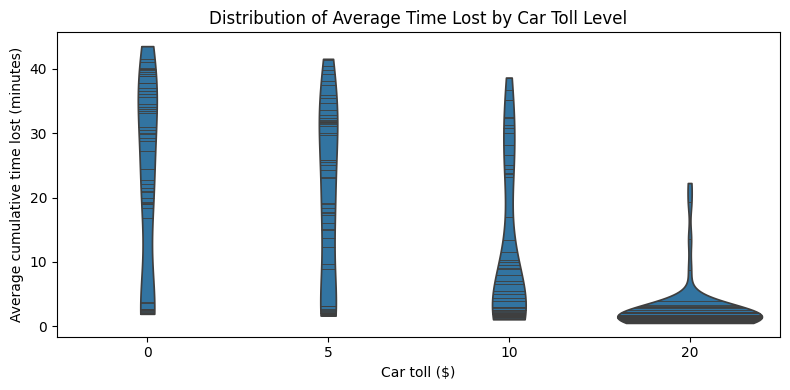

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make a minutes version for readability
df["avg_cumtime_lost_min"] = df["avg_cumtime_lost_sec"] / 60.0

plt.figure(figsize=(8, 4))

sns.violinplot(
    data=df,
    x=df["car_toll"].astype("category"),   # categorical x
    y="avg_cumtime_lost_min",
    inner="stick",        # show a little boxplot inside
    cut=0,              # don't extend beyond data range
)

plt.xlabel("Car toll ($)")
plt.ylabel("Average cumulative time lost (minutes)")
plt.title("Distribution of Average Time Lost by Car Toll Level")
plt.tight_layout()
plt.show()


# stat analysis

In [72]:
df = pd.read_csv('/Users/zanderholleran/Desktop/python_projects/mesa_lcc_model/data/traffic_experiment/single_day_experiment_results.csv')
# define 'traffic_free' if not already there
THRESH_MIN = 15.0

# For readability
df["avg_cumtime_lost_min"] = df["avg_cumtime_lost_sec"] / 60.0


df["traffic_free"] = (df["avg_cumtime_lost_min"] <= THRESH_MIN).astype(int)

df['tt_above_default'] =df['avg_realized_tt'] - 22
df['tt_above_default'] = df['tt_above_default'].clip(lower=0)


print(df["traffic_free"].value_counts())

print(df.groupby("traffic_percentile")['traffic_free'].mean())
df.head()

traffic_free
1    136
0     98
Name: count, dtype: int64
traffic_percentile
50    1.000000
70    1.000000
80    0.571429
90    0.357143
95    0.321429
Name: traffic_free, dtype: float64


,seed,traffic_percentile,car_toll,avg_realized_tt,avg_cumtime_lost_sec,bus_interval,bus_prior,n_car,n_bus,avg_cumtime_lost_min,traffic_free,tt_above_default
0,1,50,0,20.148972,121.202121,10,30,1216,0,2.020035,1,0.0
1,2,50,0,20.122597,119.578339,10,30,1276,0,1.992972,1,0.0
2,1,50,0,20.101254,118.720180,10,30,1223,0,1.978670,1,0.0
3,2,50,0,20.076228,120.349263,10,30,1283,0,2.005821,1,0.0
4,3,50,0,20.125894,120.734553,30,30,1221,0,2.012243,1,0.0


<Axes: xlabel='tt_above_default', ylabel='Count'>

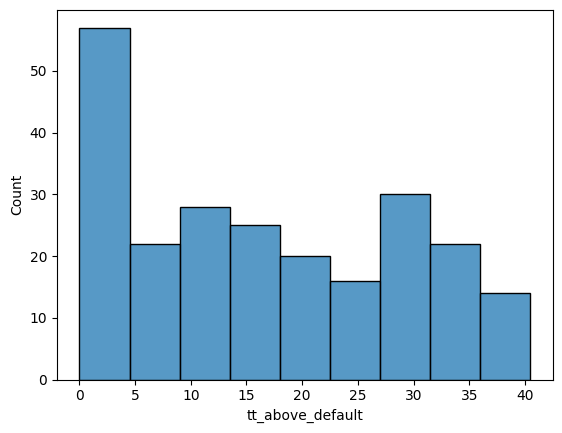

In [73]:
sns.histplot(df['tt_above_default'])

## toll crit analysis 

In [74]:
# mean traffic_free per scenario + toll
pfree = (
    df.groupby(group_cols, as_index=False)
      .agg(p_free=("traffic_free", "mean"))
)

target_p = 0.7  # e.g. 80% traffic-free days

critical_rows = []
for (tp, bp, bi), sub in pfree.groupby(["traffic_percentile", "bus_prior", "bus_interval"]):
    sub_sorted = sub.sort_values("car_toll")
    # pick smallest toll where p_free >= target
    ok = sub_sorted[sub_sorted["p_free"] >= target_p]
    if not ok.empty:
        T_star = ok["car_toll"].iloc[0]
    else:
        T_star = np.nan  # or max toll, or mark as "not enough"
    critical_rows.append({
        "traffic_percentile": tp,
        "bus_prior": bp,
        "bus_interval": bi,
        "critical_toll": T_star,
    })

crit_df = pd.DataFrame(critical_rows)
crit_df.head()

,traffic_percentile,bus_prior,bus_interval,critical_toll
0,50,30,10,0.0
1,50,30,30,0.0
2,50,40,10,0.0
3,50,40,30,0.0
4,70,30,10,0.0


In [67]:
import statsmodels.formula.api as smf

# drop scenarios where we never hit the target
crit_clean = crit_df.dropna(subset=["critical_toll"])



# assume crit_df has columns: critical_toll, traffic_percentile, bus_prior, bus_interval

df = crit_df.copy()

# rename for convenience
df["tp"] = df["traffic_percentile"]

# spline term: (tp - 71)_+
df["tp_above_70"] = np.where(df["tp"] > 71, df["tp"] - 71, 0.0)

spline_model = smf.ols(
    "critical_toll ~ tp + tp_above_70 + bus_prior + bus_interval",
    data=df
).fit()

print(spline_model.summary())


print(model.summary())


                            OLS Regression Results                            
Dep. Variable:          critical_toll   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.851
Method:                 Least Squares   F-statistic:                     39.58
Date:                Thu, 04 Dec 2025   Prob (F-statistic):           5.38e-10
Time:                        13:27:05   Log-Likelihood:                -67.861
No. Observations:                  28   AIC:                             145.7
Df Residuals:                      23   BIC:                             152.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      -24.0921      6.930     -3.476   

# Forest methods

In [116]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV


,seed,traffic_percentile,car_toll,avg_realized_tt,avg_cumtime_lost_sec,bus_interval,bus_prior,n_car,n_bus,avg_cumtime_lost_min,traffic_free,tt_above_default,low_above_default
0,1,50,0,20.148972,121.202121,10,30,1216,0,2.020035,1,0.0,1
1,2,50,0,20.122597,119.578339,10,30,1276,0,1.992972,1,0.0,1
2,1,50,0,20.101254,118.720180,10,30,1223,0,1.978670,1,0.0,1
3,2,50,0,20.076228,120.349263,10,30,1283,0,2.005821,1,0.0,1
4,3,50,0,20.125894,120.734553,30,30,1221,0,2.012243,1,0.0,1


0.3803418803418803

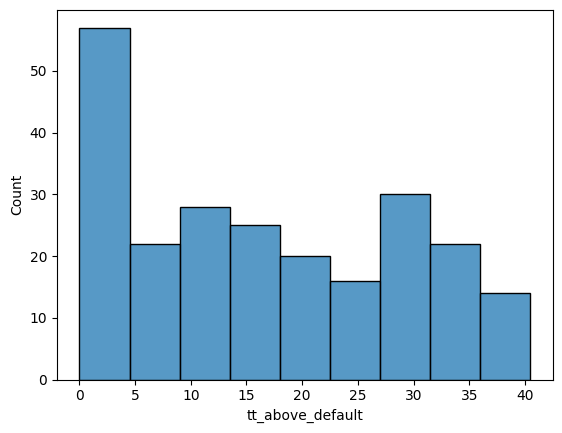

In [109]:
display(df.head())

sns.histplot(df.tt_above_default )

THRESH_tt = 10
df["low_above_default"] = (df["tt_above_default"] <= THRESH_tt).astype(int)

df["low_above_default"].mean()

=== Random forest for target: traffic_free ===
              precision    recall  f1-score   support

           0       0.88      0.78      0.82        27
           1       0.87      0.93      0.90        44

    accuracy                           0.87        71
   macro avg       0.87      0.85      0.86        71
weighted avg       0.87      0.87      0.87        71

Feature importances:
  traffic_percentile 0.423
  bus_prior          0.076
  bus_interval       0.082
  car_toll           0.419


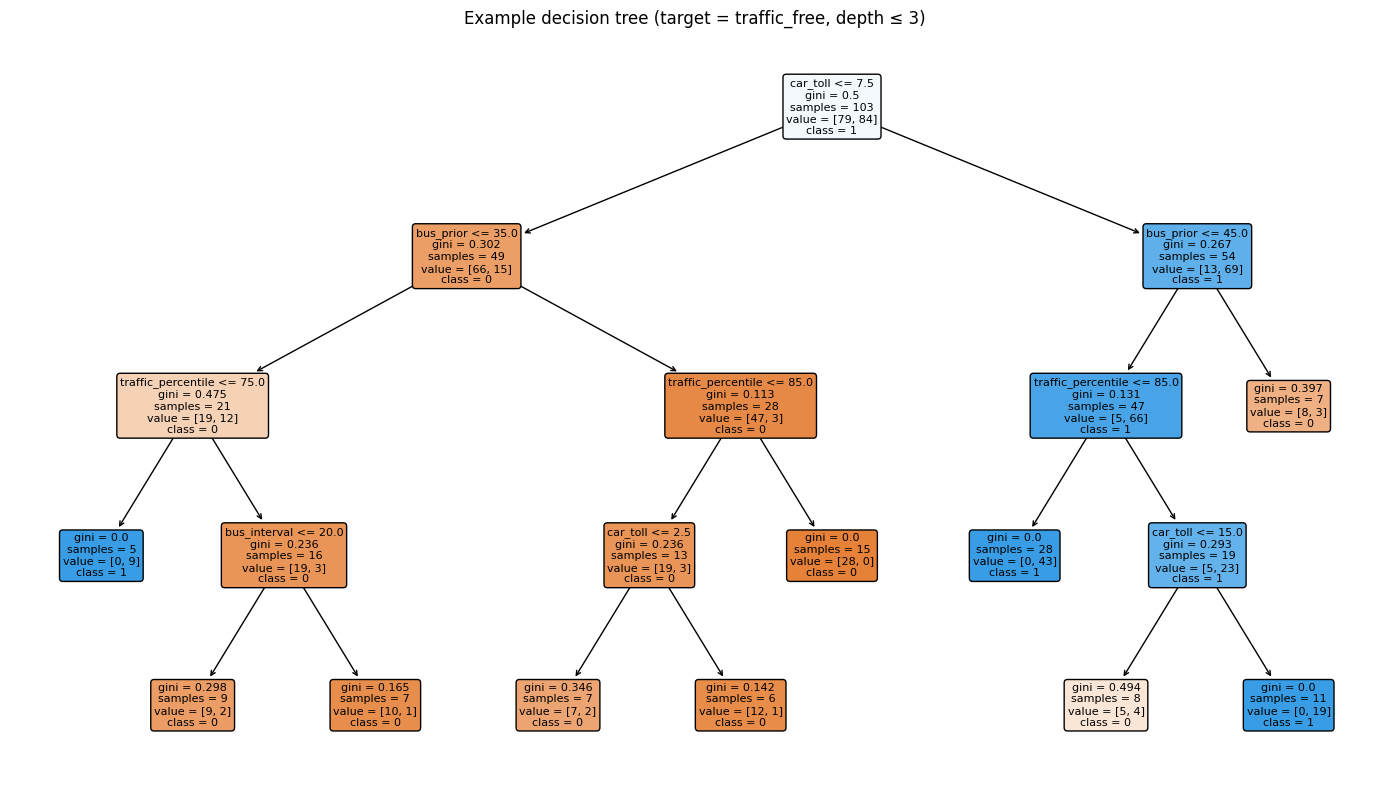

In [119]:


# --- choose target here ---
target_var = "traffic_free"        # or "low_above_default", traffic_free

# features and target
features = ["traffic_percentile", "bus_prior", "bus_interval", "car_toll"]
X = df[features]
y = df[target_var]

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# random forest
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=5,
    random_state=0,
)
rf.fit(X_train, y_train)

print(f"=== Random forest for target: {target_var} ===")
print(classification_report(y_test, rf.predict(X_test)))

print("Feature importances:")
for name, imp in zip(features, rf.feature_importances_):
    print(f"  {name:18s} {imp:0.3f}")

# --- example tree plot (first tree, truncated) ---
plt.figure(figsize=(14, 8))
plot_tree(
    rf.estimators_[0],
    feature_names=features,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True,
    max_depth=6,
    fontsize=8,
)
plt.title(f"Example decision tree (target = {target_var}, depth ≤ 3)")
plt.tight_layout()
plt.show()



## forest tuning 

In [118]:
param_grid = {
    "n_estimators": [200, 500],          # number of trees
    "max_depth": [None, 4, 8],           # allow shallow vs deeper trees
    "min_samples_leaf": [1, 3, 5],       # how many samples per leaf
    "max_features": ["sqrt", 0.8],       # features per split
}

rf_base = RandomForestClassifier(random_state=0)

grid = GridSearchCV(
    rf_base,
    param_grid,
    cv=5,
    n_jobs=-1,
    scoring="f1",   # or "roc_auc" depending on what you prefer
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)

rf = grid.best_estimator_   # this is your tuned forest

print(f"=== Random forest for target: {target_var} ===")
print(classification_report(y_test, rf.predict(X_test)))

print("Feature importances:")
for name, imp in zip(features, rf.feature_importances_):
    print(f"  {name:18s} {imp:0.3f}")



Best params: {'max_depth': 4, 'max_features': 0.8, 'min_samples_leaf': 1, 'n_estimators': 500}
=== Random forest for target: low_above_default ===
              precision    recall  f1-score   support

           0       0.76      0.95      0.85        41
           1       0.90      0.60      0.72        30

    accuracy                           0.80        71
   macro avg       0.83      0.78      0.78        71
weighted avg       0.82      0.80      0.79        71

Feature importances:
  traffic_percentile 0.659
  bus_prior          0.093
  bus_interval       0.052
  car_toll           0.195


In [85]:
def critical_toll_from_forest(rf, tp, bp, bi, toll_grid, target_p=0.8):
    grid = pd.DataFrame({
        "traffic_percentile": [tp] * len(toll_grid),
        "bus_prior": [bp] * len(toll_grid),
        "bus_interval": [bi] * len(toll_grid),
        "car_toll": toll_grid,
    })
    proba = rf.predict_proba(grid)[:, 1]  # P(traffic_free = 1)
    ok = toll_grid[proba >= target_p]
    if len(ok) == 0:
        return np.nan
    return ok[0]

toll_grid = np.linspace(df["car_toll"].min(), df["car_toll"].max(), 101)

crit_rows = []
for (tp, bp, bi), _ in df.groupby(["traffic_percentile", "bus_prior", "bus_interval"]):
    T_star = critical_toll_from_forest(rf, tp, bp, bi, toll_grid, target_p=0.8)
    crit_rows.append({
        "traffic_percentile": tp,
        "bus_prior": bp,
        "bus_interval": bi,
        "critical_toll_rf": T_star,
    })

crit_rf_df = pd.DataFrame(crit_rows)
crit_rf_df.head()


,traffic_percentile,bus_prior,bus_interval,critical_toll_rf
0,50,30,10,0.0
1,50,30,30,0.0
2,50,40,10,0.0
3,50,40,30,0.0
4,70,30,10,0.0


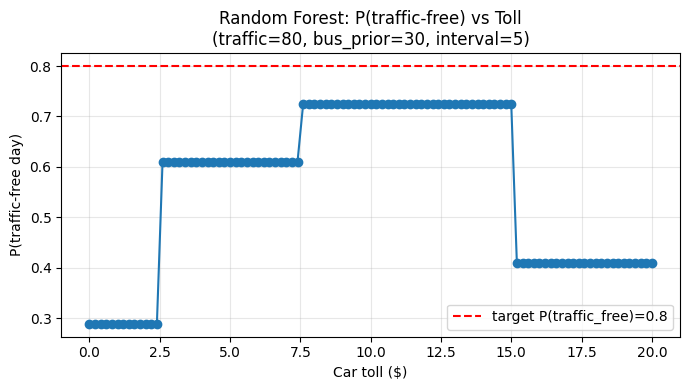

In [87]:
import matplotlib.pyplot as plt

tp_example = sorted(df["traffic_percentile"].unique())[2]
bp_example = sorted(df["bus_prior"].unique())[0]
bi_example = sorted(df["bus_interval"].unique())[0]

grid = pd.DataFrame({
    "traffic_percentile": [tp_example] * len(toll_grid),
    "bus_prior": [bp_example] * len(toll_grid),
    "bus_interval": [bi_example] * len(toll_grid),
    "car_toll": toll_grid,
})

p_free = rf.predict_proba(grid)[:, 1]

plt.figure(figsize=(7, 4))
plt.plot(toll_grid, p_free, marker="o")
plt.axhline(0.8, color="red", linestyle="--", label="target P(traffic_free)=0.8")
plt.xlabel("Car toll ($)")
plt.ylabel("P(traffic-free day)")
plt.title(f"Random Forest: P(traffic-free) vs Toll\n"
          f"(traffic={tp_example}, bus_prior={bp_example}, interval={bi_example})")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Critical tolls vs traffic percentile (bus prior 30–50)
Uses the random forest to estimate the toll that achieves P(traffic_free) ≥ 0.8,
varying bus prior in [30, 50] while holding bus interval constant.

In [ ]:
# sample across traffic_percentile and bus_prior ranges
tp_grid = np.linspace(df['traffic_percentile'].min(), df['traffic_percentile'].max(), 40)
bp_grid = np.linspace(30, 50, 25)
bus_interval_fixed = float(df['bus_interval'].mode().iat[0])

crit_grid_rows = []
for tp in tp_grid:
    for bp in bp_grid:
        T_star = critical_toll_from_forest(rf, tp, bp, bus_interval_fixed, toll_grid, target_p=0.8)
        crit_grid_rows.append({
            'traffic_percentile': tp,
            'bus_prior': bp,
            'bus_interval': bus_interval_fixed,
            'critical_toll_rf': T_star,
        })

crit_grid_df = pd.DataFrame(crit_grid_rows).dropna(subset=['critical_toll_rf'])

plt.figure(figsize=(7.5, 4.5))
ax = sns.regplot(
    data=crit_grid_df,
    x='traffic_percentile',
    y='critical_toll_rf',
    scatter=False,
    ci=95,
    color='black',
    line_kws={'lw': 2},
)
sns.scatterplot(
    data=crit_grid_df,
    x='traffic_percentile',
    y='critical_toll_rf',
    hue='bus_prior',
    palette='viridis',
    alpha=0.5,
    edgecolor=None,
    ax=ax,
)
ax.set_title(f'Predicted critical tolls (bus_interval={bus_interval_fixed:.0f})')
ax.set_xlabel('Traffic percentile')
ax.set_ylabel('Critical toll ($)')
ax.legend(title='Bus prior')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 3d plotting

In [121]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
df.head()

,seed,traffic_percentile,car_toll,avg_realized_tt,avg_cumtime_lost_sec,bus_interval,bus_prior,n_car,n_bus,avg_cumtime_lost_min,traffic_free,tt_above_default,low_above_default
0,1,50,0,20.148972,121.202121,10,30,1216,0,2.020035,1,0.0,1
1,2,50,0,20.122597,119.578339,10,30,1276,0,1.992972,1,0.0,1
2,1,50,0,20.101254,118.720180,10,30,1223,0,1.978670,1,0.0,1
3,2,50,0,20.076228,120.349263,10,30,1283,0,2.005821,1,0.0,1
4,3,50,0,20.125894,120.734553,30,30,1221,0,2.012243,1,0.0,1


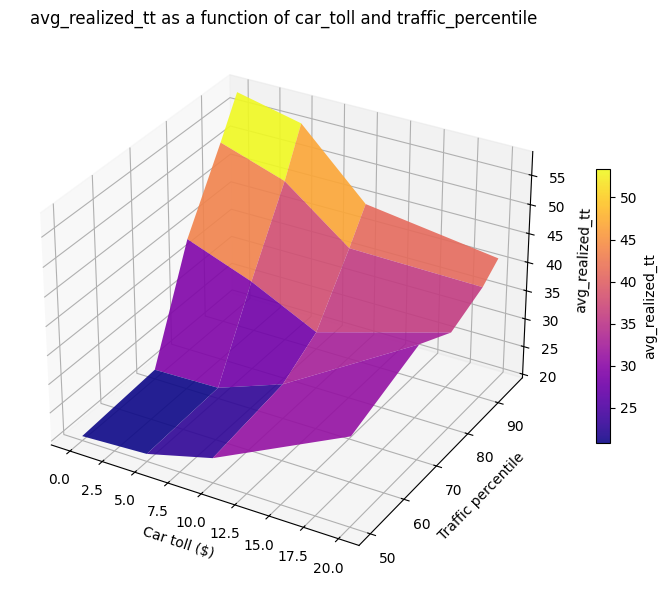

In [127]:
target_var = "avg_realized_tt"  # you can swap this to another continuous target

# Aggregate to get one value per (traffic_percentile, car_toll)
g = (
    df.groupby(["traffic_percentile", "car_toll"], as_index=False)[target_var]
      .mean()
)

tolls = sorted(g["car_toll"].unique())
tps = sorted(g["traffic_percentile"].unique())

Z_pivot = g.pivot(index="traffic_percentile", columns="car_toll", values=target_var)
Z = Z_pivot.values
X, Y = np.meshgrid(tolls, tps)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(X, Y, Z, cmap="plasma", edgecolor="none", alpha=0.9)

ax.set_xlabel("Car toll ($)")
ax.set_ylabel("Traffic percentile")
ax.set_zlabel(target_var)
ax.set_title(f"{target_var} as a function of car_toll and traffic_percentile")

fig.colorbar(surf, shrink=0.5, aspect=20, label=target_var)

plt.tight_layout()
plt.show()